In [1]:
import os
from tqdm import tqdm

from modules.utils import read_pdf, read_questions, save_json
from modules.semantic_layer import SemanticLayer
from modules.statistical_layer import StatisticalLayer
from modules.bloom_classifier import BloomClassifier
from modules.clo_alignment import CLOAlignment


# ==============================
# 1. PATH CONFIG
# ==============================

BASE_PATH = r"G:\My Drive\Hoạt động nghiên cứu\Đề tài\15032026_AI nâng cao hiệu quả giáo dục\AI bloom taxonomy\Modules\aqvf\data"

CLO_JSON = os.path.join(BASE_PATH, "clo.json")
LECTURE_PDF = os.path.join(BASE_PATH, "lecturer.pdf")
PRACTICE_PDF = os.path.join(BASE_PATH, "pratical.pdf")
TRAIN_CSV = os.path.join(BASE_PATH, "OOP.csv")
TEST_CSV = os.path.join(BASE_PATH, "OOP.csv")


# ==============================
# 2. LOAD DATA
# ==============================

lecture_text = read_pdf(LECTURE_PDF)
practice_text = read_pdf(PRACTICE_PDF)

knowledge_base = [lecture_text, practice_text]

train_df = read_questions(TRAIN_CSV)
test_df = read_questions(TEST_CSV)


# ==============================
# 3. INIT MODELS
# ==============================

# Bloom classifier (TF-IDF + SVM)
bloom_model = BloomClassifier()
bloom_model.train(TRAIN_CSV)

# Semantic layer
semantic_layer = SemanticLayer()
semantic_layer.build_knowledge_base(knowledge_base)

# CLO alignment (embedding-based)
clo_mapper = CLOAlignment(CLO_JSON, similarity_threshold=0.3)

# Statistical simulation
stat_layer = StatisticalLayer()


# ==============================
# 4. PIPELINE
# ==============================

qa_results = []

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):

    question_id = int(idx) + 1
    question_text = row["question"]
    labeled_bloom = row["label"]

    # 1️⃣ Semantic Analysis
    semantic_scores = semantic_layer.analyze_question(question_text)

    # 2️⃣ Bloom Prediction
    predicted_bloom, bloom_conf = bloom_model.predict(
        question_text,
        return_confidence=True
    )

    bloom_consistency = predicted_bloom == labeled_bloom

    # 3️⃣ CLO Alignment (NEW VERSION)
    clo_result = clo_mapper.map_question(question_text)

    # 4️⃣ Statistical Estimation
    difficulty = stat_layer.simulate_difficulty(
        semantic_scores["semantic_relevance"],
        predicted_bloom
    )

    discrimination = stat_layer.simulate_discrimination(difficulty)

    qa_results.append({
        "question_id": question_id,
        "question": question_text,

        # Semantic
        "semantic_relevance": semantic_scores["semantic_relevance"],
        "avg_similarity": semantic_scores["avg_similarity"],

        # Bloom
        "bloom_label": labeled_bloom,
        "predicted_label": predicted_bloom,
        "bloom_confidence": bloom_conf,
        "bloom_consistent": bloom_consistency,

        # CLO
        "best_clo": clo_result["best_clo"],
        "clo_similarity": clo_result["similarity"],
        "all_clo_scores": clo_result["all_scores"],
        "cci": clo_result["cci"],
        "matched_clo_count": clo_result["matched_clo_count"],

        # Statistical
        "difficulty_estimated": difficulty,
        "discrimination_estimated": discrimination
    })


# ==============================
# 5. SAVE RESULT
# ==============================

output_path = os.path.join(BASE_PATH, "aqvf_results_main_questions.json")

save_json({
    "total_questions": len(qa_results),
    "results": qa_results
}, output_path)

print("\n✅ AQVF analysis completed successfully.")
print("📁 Saved to:", output_path)

# ==============================
# 6. GLOBAL COVERAGE ANALYSIS
# ==============================

all_questions = test_df["question"].tolist()

coverage_result = semantic_layer.compute_coverage(
    all_questions,
    threshold=0.4
)

# Gán CCI từng câu vào kết quả
for i in range(len(qa_results)):
    qa_results[i]["question_coverage_index"] = coverage_result["question_cci"][i]

# Thêm corpus coverage
final_output = {
    "total_questions": len(qa_results),
    "total_chunks": coverage_result["total_chunks"],
    "corpus_coverage": coverage_result["corpus_coverage"],
    "results": qa_results
}

save_json(final_output, output_path)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Bloom classifier accuracy: 0.9250


100%|██████████| 600/600 [00:09<00:00, 60.61it/s]



✅ AQVF analysis completed successfully.
📁 Saved to: G:\My Drive\Hoạt động nghiên cứu\Đề tài\15032026_AI nâng cao hiệu quả giáo dục\AI bloom taxonomy\Modules\aqvf\data\aqvf_results_main_questions.json



QUESTION 1:
Định nghĩa lập trình hướng đối tượng (OOP).

=== Cosine Similarity (Question 1 vs CLOs) ===
CLO1: 0.5104
CLO2: 0.2293
CLO3: 0.4011
CLO4: 0.3494

=> Highest similarity: CLO1


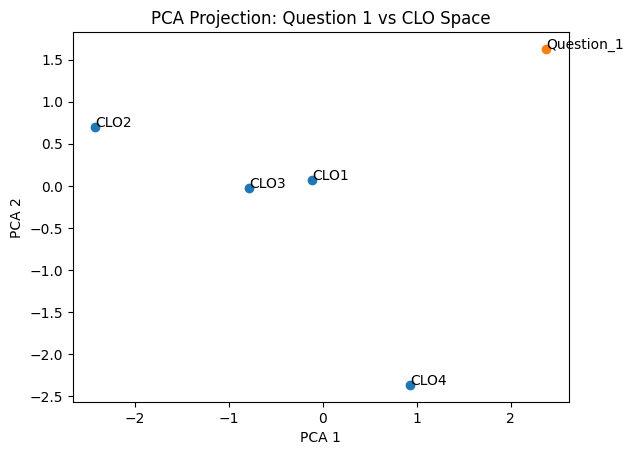

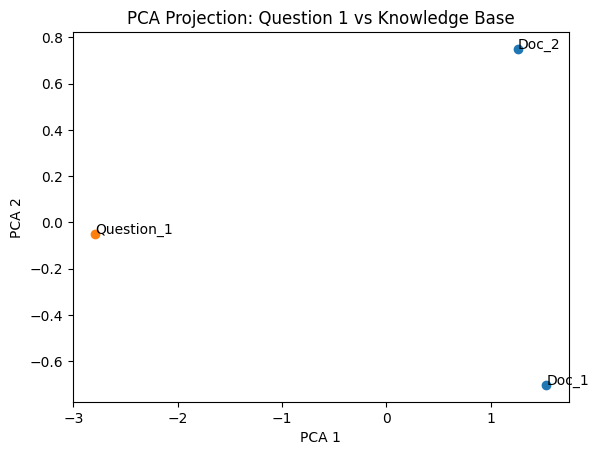


=== Cosine Similarity (Question 1 vs Knowledge Base) ===
Doc_1: 0.2849
Doc_2: 0.2402


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity


# ==============================
# 1. LOAD CLO DATA (CORRECT FORMAT)
# ==============================

with open(CLO_JSON, "r", encoding="utf-8") as f:
    clo_data = json.load(f)

clo_ids = [item["clo_id"] for item in clo_data]
clo_texts = [item["description"] for item in clo_data]


# ==============================
# 2. GET QUESTION 1
# ==============================

q1 = next(item for item in qa_results if item["question_id"] == 1)
question_text = q1["question"]

print("\n==============================")
print("QUESTION 1:")
print(question_text)
print("==============================\n")


# ==============================
# 3. EMBEDDING MODEL
# ==============================

embedding_model = semantic_layer.model

q_embedding = embedding_model.encode([question_text])[0]
clo_embeddings = embedding_model.encode(clo_texts)


# ==============================
# 4. COSINE SIMILARITY (WHY THIS CLO?)
# ==============================

print("=== Cosine Similarity (Question 1 vs CLOs) ===")

similarities = []

for i, clo_id in enumerate(clo_ids):
    sim = cosine_similarity(
        q_embedding.reshape(1, -1),
        clo_embeddings[i].reshape(1, -1)
    )[0][0]

    similarities.append(sim)
    print(f"{clo_id}: {sim:.4f}")

best_index = np.argmax(similarities)
print("\n=> Highest similarity:", clo_ids[best_index])


# ==============================
# 5. PCA VISUALIZATION: QUESTION vs CLO
# ==============================

combined = np.vstack([q_embedding, clo_embeddings])

pca = PCA(n_components=2)
reduced = pca.fit_transform(combined)

q_point = reduced[0]
clo_points = reduced[1:]

plt.figure()
plt.scatter(clo_points[:, 0], clo_points[:, 1])
plt.scatter(q_point[0], q_point[1])

for i, clo_id in enumerate(clo_ids):
    plt.text(clo_points[i, 0], clo_points[i, 1], clo_id)

plt.text(q_point[0], q_point[1], "Question_1")

plt.title("PCA Projection: Question 1 vs CLO Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


# ==============================
# 6. EMBEDDING CLUSTER: QUESTION vs KNOWLEDGE BASE
# ==============================

kb_embeddings = embedding_model.encode(knowledge_base)

combined_kb = np.vstack([q_embedding, kb_embeddings])

pca2 = PCA(n_components=2)
reduced_kb = pca2.fit_transform(combined_kb)

q_point_kb = reduced_kb[0]
doc_points = reduced_kb[1:]

plt.figure()
plt.scatter(doc_points[:, 0], doc_points[:, 1])
plt.scatter(q_point_kb[0], q_point_kb[1])

for i in range(len(doc_points)):
    plt.text(doc_points[i, 0], doc_points[i, 1], f"Doc_{i+1}")

plt.text(q_point_kb[0], q_point_kb[1], "Question_1")

plt.title("PCA Projection: Question 1 vs Knowledge Base")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


# ==============================
# 7. COSINE SIMILARITY WITH DOCS
# ==============================

print("\n=== Cosine Similarity (Question 1 vs Knowledge Base) ===")

for i, emb in enumerate(kb_embeddings):
    sim = cosine_similarity(
        q_embedding.reshape(1, -1),
        emb.reshape(1, -1)
    )[0][0]

    print(f"Doc_{i+1}: {sim:.4f}")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import normalize

embedding_model = semantic_layer.model

# Question 1
q1 = next(item for item in qa_results if item["question_id"] == 1)
question_text = q1["question"]
q_embedding = embedding_model.encode([question_text])[0]

# CLO
clo_embeddings = embedding_model.encode(clo_texts)

# Similarity matrix
similarity_scores = cosine_similarity(
    q_embedding.reshape(1, -1),
    clo_embeddings
)[0]

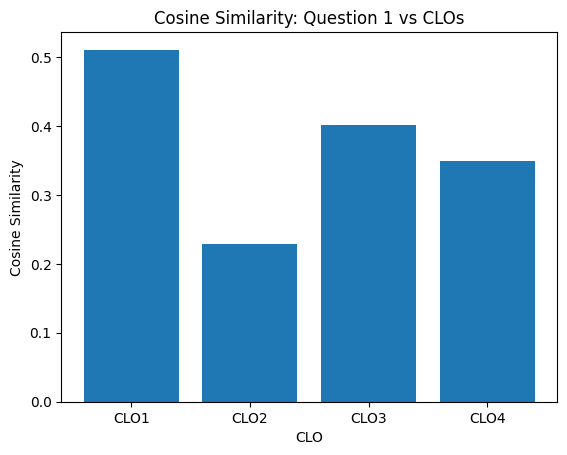

In [4]:
plt.figure()
plt.bar(clo_ids, similarity_scores)
plt.title("Cosine Similarity: Question 1 vs CLOs")
plt.xlabel("CLO")
plt.ylabel("Cosine Similarity")
plt.show()

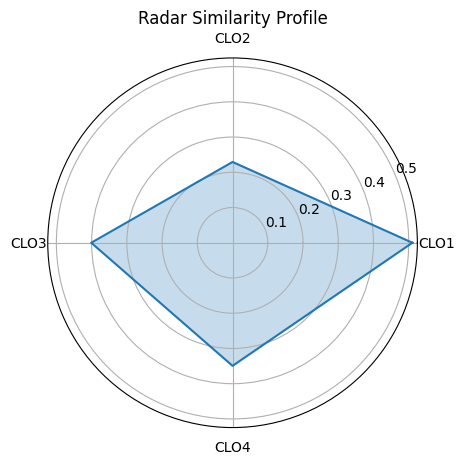

In [5]:
labels = clo_ids
values = list(similarity_scores)

values += values[:1]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure()
ax = plt.subplot(111, polar=True)
ax.plot(angles, values)
ax.fill(angles, values, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
plt.title("Radar Similarity Profile")
plt.show()

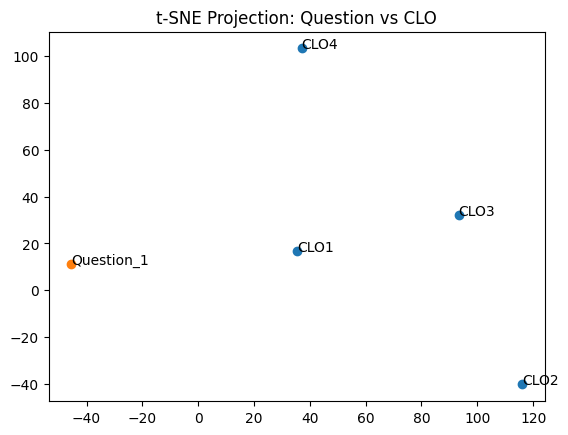

In [6]:
combined = np.vstack([q_embedding, clo_embeddings])

tsne = TSNE(n_components=2, random_state=42, perplexity=3)
reduced = tsne.fit_transform(combined)

q_point = reduced[0]
clo_points = reduced[1:]

plt.figure()
plt.scatter(clo_points[:, 0], clo_points[:, 1])
plt.scatter(q_point[0], q_point[1])

for i, clo_id in enumerate(clo_ids):
    plt.text(clo_points[i, 0], clo_points[i, 1], clo_id)

plt.text(q_point[0], q_point[1], "Question_1")

plt.title("t-SNE Projection: Question vs CLO")
plt.show()

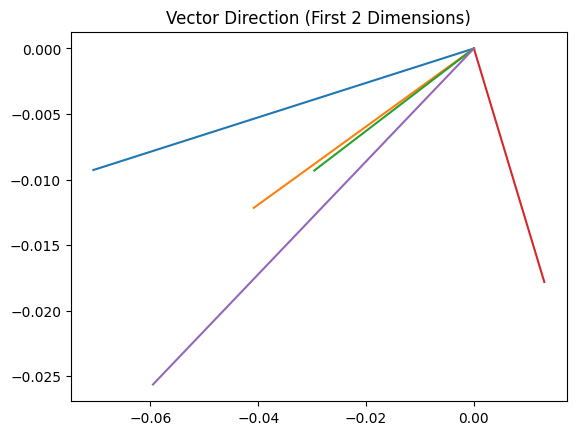

In [7]:
norm_embeddings = normalize(np.vstack([q_embedding, clo_embeddings]))

plt.figure()

origin = np.zeros(len(norm_embeddings[0]))

for i, clo_id in enumerate(clo_ids):
    plt.plot(
        [0, norm_embeddings[i+1][0]],
        [0, norm_embeddings[i+1][1]]
    )

plt.plot(
    [0, norm_embeddings[0][0]],
    [0, norm_embeddings[0][1]]
)

plt.title("Vector Direction (First 2 Dimensions)")
plt.show()

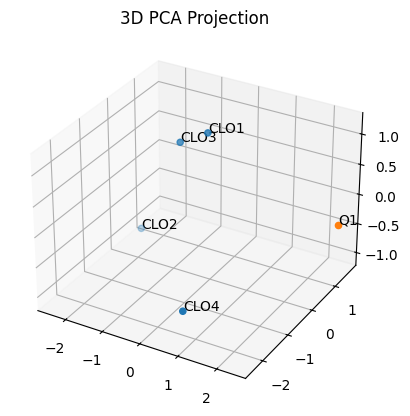

In [8]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
reduced3 = pca3.fit_transform(np.vstack([q_embedding, clo_embeddings]))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced3[1:,0], reduced3[1:,1], reduced3[1:,2])
ax.scatter(reduced3[0,0], reduced3[0,1], reduced3[0,2])

for i, clo_id in enumerate(clo_ids):
    ax.text(reduced3[i+1,0], reduced3[i+1,1], reduced3[i+1,2], clo_id)

ax.text(reduced3[0,0], reduced3[0,1], reduced3[0,2], "Q1")

plt.title("3D PCA Projection")
plt.show()

Total Questions: 50
Bloom Accuracy: 1.0
Confusion Matrix:
Predicted  BT1  BT2  BT3  BT4  BT5  BT6
True                                   
BT1          9    0    0    0    0    0
BT2          0    8    0    0    0    0
BT3          0    0    8    0    0    0
BT4          0    0    0    9    0    0
BT5          0    0    0    0    8    0
BT6          0    0    0    0    0    8
True Bloom Distribution:
bloom_label
BT1    9
BT2    8
BT3    8
BT4    9
BT5    8
BT6    8
Name: count, dtype: int64
Predicted Bloom Distribution:
predicted_label
BT1    9
BT2    8
BT3    8
BT4    9
BT5    8
BT6    8
Name: count, dtype: int64


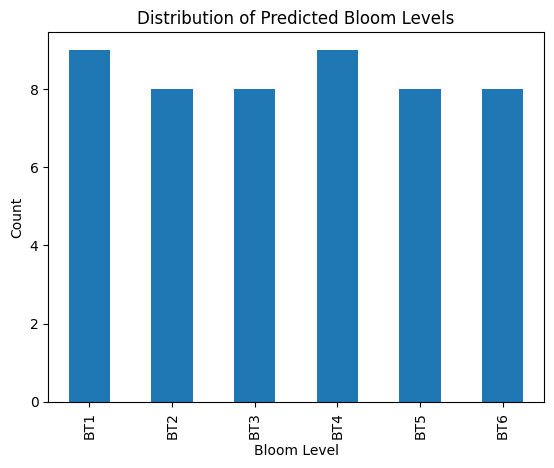

Difficulty statistics:
count    50.000000
mean      0.360507
std       0.140820
min       0.142655
25%       0.222509
50%       0.377396
75%       0.495445
max       0.584195
Name: difficulty_estimated, dtype: float64


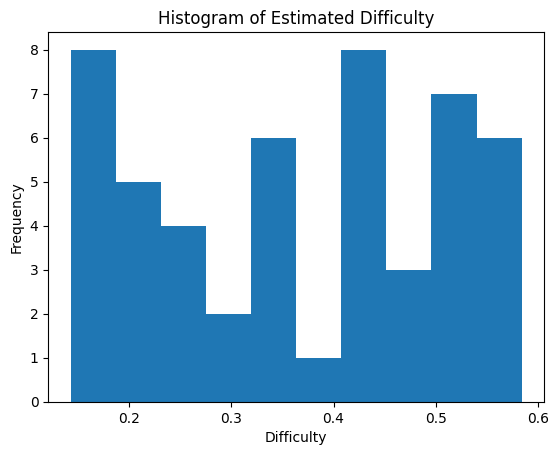

Discrimination statistics:
count    50.000000
mean      0.844432
std       0.175029
min       0.489217
25%       0.691682
50%       0.936890
75%       0.992354
max       0.999985
Name: discrimination_estimated, dtype: float64


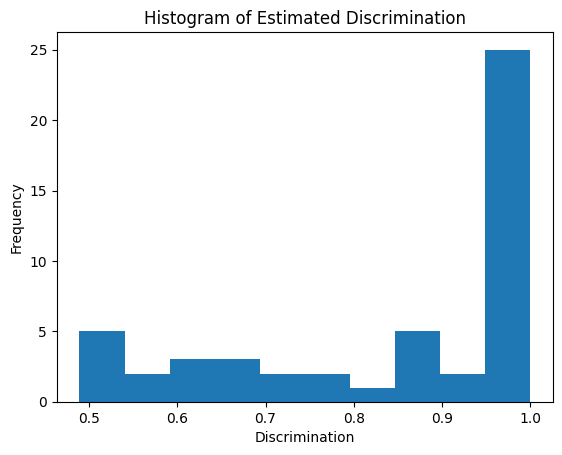

CLO Distribution:
best_clo
CLO1    22
CLO2    15
CLO3     8
CLO4     5
Name: count, dtype: int64
CLO Ratio (%):
best_clo
CLO1    44.0
CLO2    30.0
CLO3    16.0
CLO4    10.0
Name: count, dtype: float64


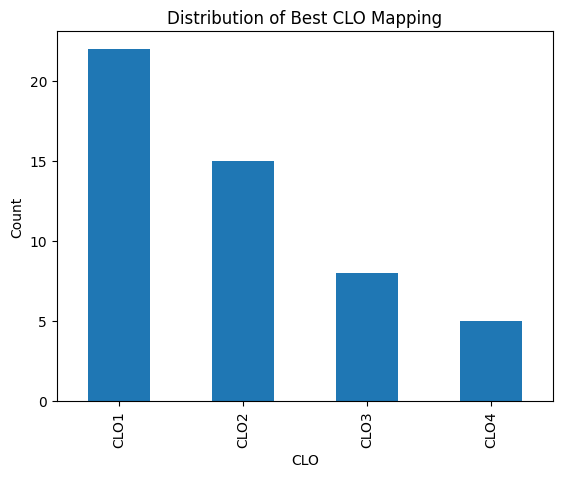

In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# LOAD FILE
# ===============================

with open(r"G:\My Drive\Hoạt động nghiên cứu\Đề tài\15032026_AI nâng cao hiệu quả giáo dục\AI bloom taxonomy\Modules\aqvf\data\aqvf_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["results"])

print("Total Questions:", len(df))
print("===================================")

# ===============================
# 1️⃣ BLOOM ACCURACY
# ===============================

accuracy = (df["bloom_label"] == df["predicted_label"]).mean()
print("Bloom Accuracy:", round(accuracy, 4))
print("===================================")

# Confusion matrix
conf_matrix = pd.crosstab(
    df["bloom_label"],
    df["predicted_label"],
    rownames=["True"],
    colnames=["Predicted"]
)

print("Confusion Matrix:")
print(conf_matrix)
print("===================================")

# ===============================
# 2️⃣ BLOOM DISTRIBUTION
# ===============================

true_dist = df["bloom_label"].value_counts().sort_index()
pred_dist = df["predicted_label"].value_counts().sort_index()

print("True Bloom Distribution:")
print(true_dist)
print("===================================")

print("Predicted Bloom Distribution:")
print(pred_dist)
print("===================================")

# Plot predicted distribution
plt.figure()
pred_dist.plot(kind="bar")
plt.title("Distribution of Predicted Bloom Levels")
plt.xlabel("Bloom Level")
plt.ylabel("Count")
plt.show()

# ===============================
# 3️⃣ DIFFICULTY HISTOGRAM
# ===============================

print("Difficulty statistics:")
print(df["difficulty_estimated"].describe())
print("===================================")

plt.figure()
plt.hist(df["difficulty_estimated"], bins=10)
plt.title("Histogram of Estimated Difficulty")
plt.xlabel("Difficulty")
plt.ylabel("Frequency")
plt.show()

# ===============================
# 4️⃣ DISCRIMINATION HISTOGRAM
# ===============================

print("Discrimination statistics:")
print(df["discrimination_estimated"].describe())
print("===================================")

plt.figure()
plt.hist(df["discrimination_estimated"], bins=10)
plt.title("Histogram of Estimated Discrimination")
plt.xlabel("Discrimination")
plt.ylabel("Frequency")
plt.show()

# ===============================
# 5️⃣ CLO BIAS CHECK
# ===============================

if "best_clo" in df.columns:
    
    clo_dist = df["best_clo"].value_counts()
    
    print("CLO Distribution:")
    print(clo_dist)
    print("===================================")
    
    # Tính tỷ lệ %
    clo_ratio = clo_dist / len(df)
    
    print("CLO Ratio (%):")
    print((clo_ratio * 100).round(2))
    print("===================================")
    
    plt.figure()
    clo_dist.sort_index().plot(kind="bar")
    plt.title("Distribution of Best CLO Mapping")
    plt.xlabel("CLO")
    plt.ylabel("Count")
    plt.show()

else:
    print("No best_clo column found.")

In [10]:
import json
import numpy as np
import pandas as pd

RESULT_PATH = r"G:\My Drive\Hoạt động nghiên cứu\Đề tài\15032026_AI nâng cao hiệu quả giáo dục\AI bloom taxonomy\Modules\aqvf\data\aqvf_results.json"

# ==============================
# LOAD FILE
# ==============================

with open(RESULT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["results"])

print("======================================")
print("TỔNG SỐ CÂU:", len(df))
print("======================================\n")


# ==============================
# 1️⃣ THỐNG KÊ TỔNG QUAN
# ==============================

print("=== SEMANTIC ===")
print(df["semantic_relevance"].describe(), "\n")

print("=== DIFFICULTY ===")
print(df["difficulty_estimated"].describe(), "\n")

print("=== DISCRIMINATION ===")
print(df["discrimination_estimated"].describe(), "\n")

print("=== BLOOM ACCURACY ===")
accuracy = df["bloom_consistent"].mean()
print("Accuracy:", round(accuracy, 4), "\n")


# ==============================
# 2️⃣ TÌM CÂU BẤT THƯỜNG
# ==============================

print("======================================")
print("CÂU CÓ SEMANTIC QUÁ THẤP (<0.25)")
print("======================================")

low_semantic = df[df["semantic_relevance"] < 0.25]
print("Số câu:", len(low_semantic))
print(low_semantic[["question_id", "semantic_relevance"]].head())


print("\n======================================")
print("CÂU CÓ DIFFICULTY QUÁ CAO (>0.9)")
print("======================================")

high_difficulty = df[df["difficulty_estimated"] > 0.9]
print("Số câu:", len(high_difficulty))
print(high_difficulty[["question_id", "difficulty_estimated"]].head())


print("\n======================================")
print("CÂU CÓ DISCRIMINATION THẤP (<0.2)")
print("======================================")

low_disc = df[df["discrimination_estimated"] < 0.2]
print("Số câu:", len(low_disc))
print(low_disc[["question_id", "difficulty_estimated", "discrimination_estimated"]].head())


print("\n======================================")
print("CÂU BLOOM SAI NHÃN")
print("======================================")

wrong_bloom = df[df["bloom_consistent"] == False]
print("Số câu:", len(wrong_bloom))
print(wrong_bloom[["question_id", "bloom_label", "predicted_label", "bloom_confidence"]].head())


# ==============================
# 3️⃣ CHECK CLO BIAS
# ==============================

print("\n======================================")
print("PHÂN PHỐI CLO")
print("======================================")

clo_distribution = df["best_clo"].value_counts(normalize=True)
print(clo_distribution)

if clo_distribution.max() > 0.6:
    print("\n⚠️ CẢNH BÁO: CLO mapping có thể bị bias về", clo_distribution.idxmax())


print("\n======================================")
print("PHÂN TÍCH HOÀN TẤT")
print("======================================")

TỔNG SỐ CÂU: 50

=== SEMANTIC ===
count    50.000000
mean      0.803405
std       0.048809
min       0.701749
25%       0.769619
50%       0.810347
75%       0.837776
max       0.895384
Name: semantic_relevance, dtype: float64 

=== DIFFICULTY ===
count    50.000000
mean      0.360507
std       0.140820
min       0.142655
25%       0.222509
50%       0.377396
75%       0.495445
max       0.584195
Name: difficulty_estimated, dtype: float64 

=== DISCRIMINATION ===
count    50.000000
mean      0.844432
std       0.175029
min       0.489217
25%       0.691682
50%       0.936890
75%       0.992354
max       0.999985
Name: discrimination_estimated, dtype: float64 

=== BLOOM ACCURACY ===
Accuracy: 1.0 

CÂU CÓ SEMANTIC QUÁ THẤP (<0.25)
Số câu: 0
Empty DataFrame
Columns: [question_id, semantic_relevance]
Index: []

CÂU CÓ DIFFICULTY QUÁ CAO (>0.9)
Số câu: 0
Empty DataFrame
Columns: [question_id, difficulty_estimated]
Index: []

CÂU CÓ DISCRIMINATION THẤP (<0.2)
Số câu: 0
Empty DataFrame
Colu

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

embedding_model = semantic_layer.model

# Question 1
q1 = next(item for item in qa_results if item["question_id"] == 1)
question_text = q1["question"]
q_embedding = embedding_model.encode([question_text])[0]

# CLO
clo_embeddings = embedding_model.encode(clo_texts)

# Normalize để dễ so sánh hướng vector
q_norm = normalize(q_embedding.reshape(1, -1))[0]
clo_norm = normalize(clo_embeddings)

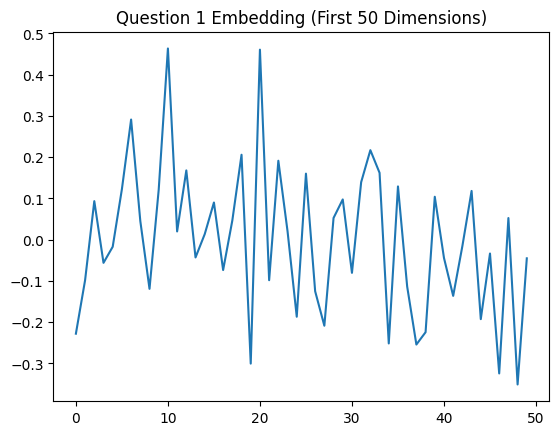

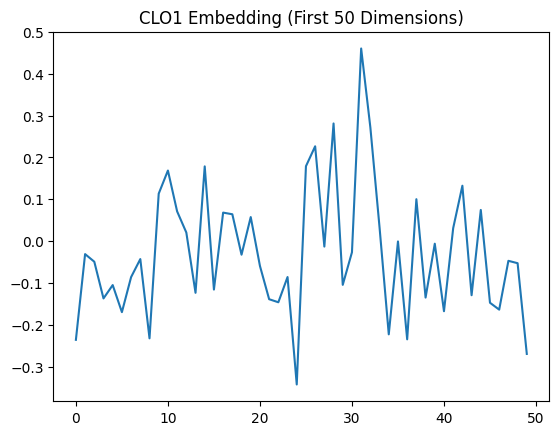

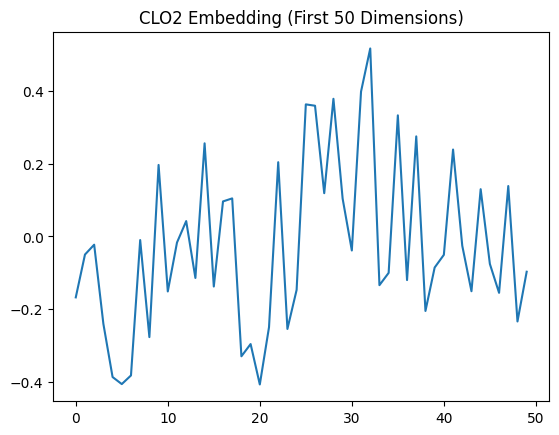

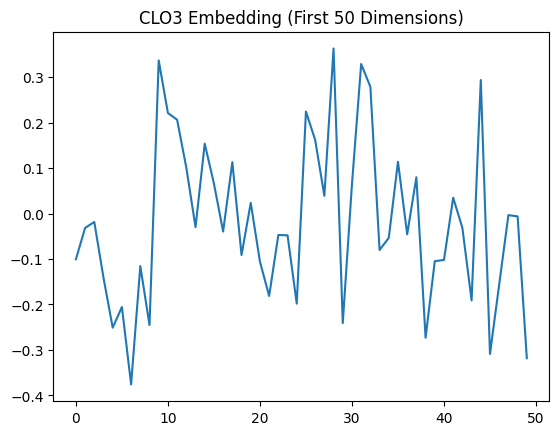

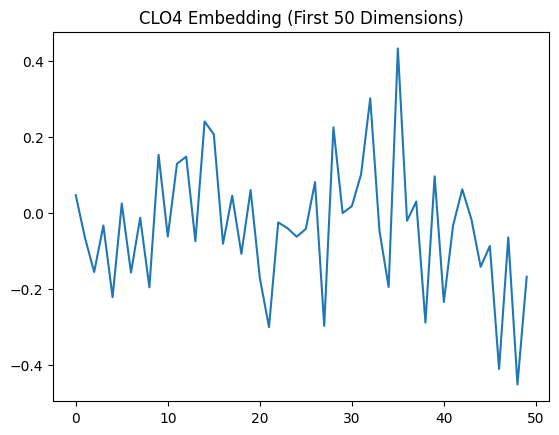

In [12]:
plt.figure()
plt.plot(q_embedding[:50])
plt.title("Question 1 Embedding (First 50 Dimensions)")
plt.show()

for i, clo_id in enumerate(clo_ids):
    plt.figure()
    plt.plot(clo_embeddings[i][:50])
    plt.title(f"{clo_id} Embedding (First 50 Dimensions)")
    plt.show()

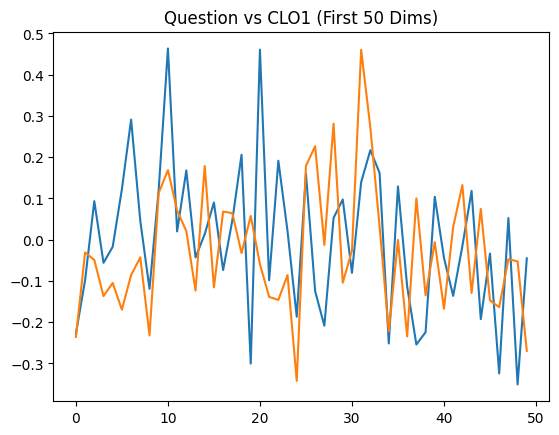

In [13]:
best_index = np.argmax(
    cosine_similarity(q_embedding.reshape(1, -1), clo_embeddings)[0]
)

plt.figure()
plt.plot(q_embedding[:50])
plt.plot(clo_embeddings[best_index][:50])
plt.title(f"Question vs {clo_ids[best_index]} (First 50 Dims)")
plt.show()

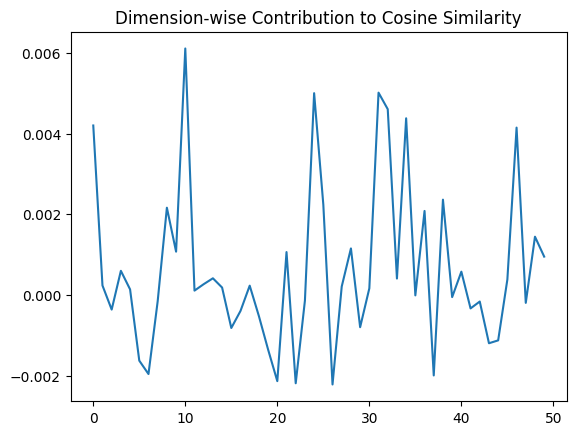

In [14]:
contribution = q_norm * clo_norm[best_index]

plt.figure()
plt.plot(contribution[:50])
plt.title("Dimension-wise Contribution to Cosine Similarity")
plt.show()

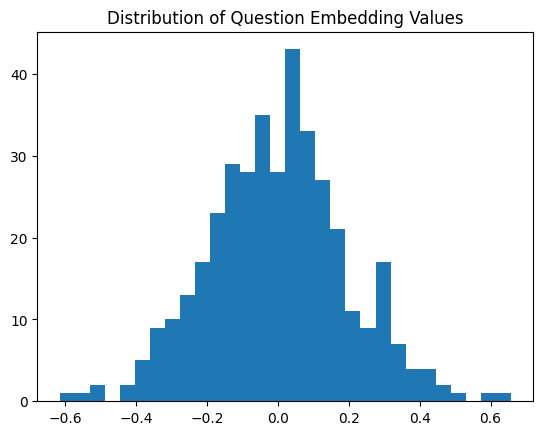

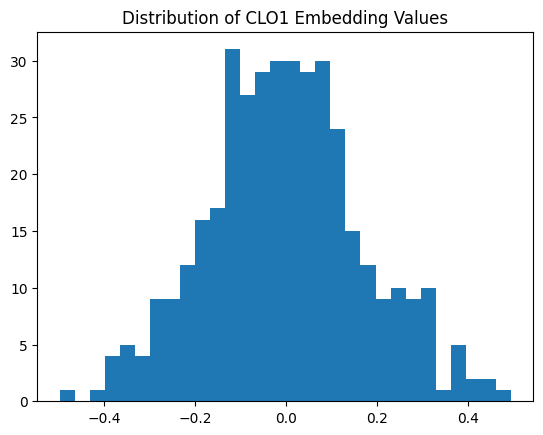

In [15]:
plt.figure()
plt.hist(q_embedding, bins=30)
plt.title("Distribution of Question Embedding Values")
plt.show()

plt.figure()
plt.hist(clo_embeddings[best_index], bins=30)
plt.title(f"Distribution of {clo_ids[best_index]} Embedding Values")
plt.show()

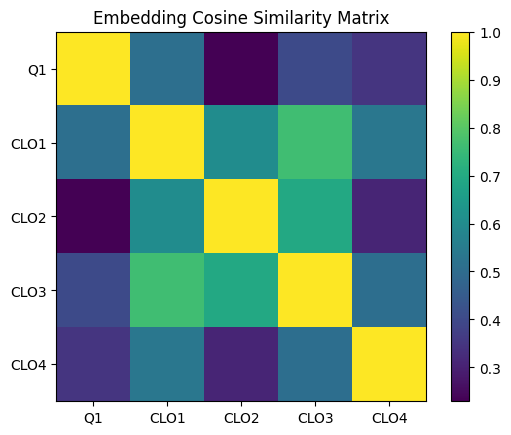

In [16]:
matrix = cosine_similarity(
    np.vstack([q_embedding, clo_embeddings])
)

plt.figure()
plt.imshow(matrix)
plt.colorbar()
plt.title("Embedding Cosine Similarity Matrix")
plt.xticks(range(len(clo_ids)+1), ["Q1"] + clo_ids)
plt.yticks(range(len(clo_ids)+1), ["Q1"] + clo_ids)
plt.show()

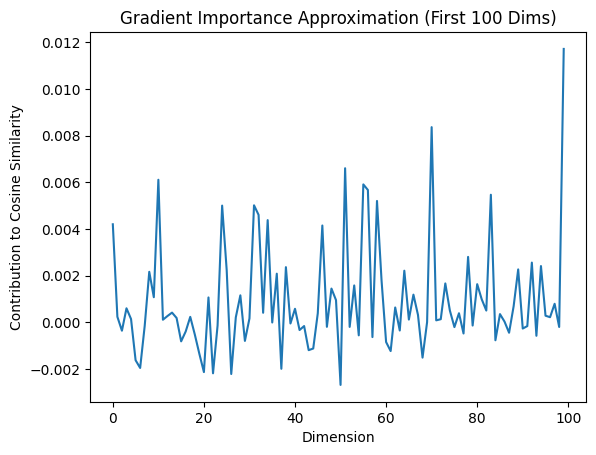

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

# Lấy CLO có similarity cao nhất
similarities = cosine_similarity(
    q_embedding.reshape(1, -1),
    clo_embeddings
)[0]

best_index = np.argmax(similarities)
best_clo_embedding = clo_embeddings[best_index]

# Gradient approximation
grad_importance = normalize(q_embedding.reshape(1, -1))[0] * \
                  normalize(best_clo_embedding.reshape(1, -1))[0]

plt.figure()
plt.plot(grad_importance[:100])
plt.title("Gradient Importance Approximation (First 100 Dims)")
plt.xlabel("Dimension")
plt.ylabel("Contribution to Cosine Similarity")
plt.show()